# 07 — Graph-construction ablation (Task 1)

nb05 trained node2vec on a **Compound ∪ Gene ∪ Disease** induced subgraph. This notebook asks the obvious next question: what if we widened, or narrowed, the walk graph? Four variants, all evaluated on the **locked** split and pair universe from nb04:

| Variant | Nodes kept | Edges kept | Motivation |
|---|---|---|---|
| **V1 — CtD only** | Compound + Disease | CtD only (test edges removed) | Lower bound. Shows how much signal is in the direct Compound–treats–Disease edges alone. |
| **V2 — CGD** | Compound + Gene + Disease | all edges among these kinds | nb05's baseline. |
| **V3 — Full** | all 11 node kinds | all edges | Upper bound. Does anatomy / side-effect / biological-process structure add anything, or is it noise for a random walker? |
| **V4 — CtD + metapath shortcuts** | Compound + Disease | CtD + weighted C→G→D shortcuts | Middle ground. Keep the graph small (V1-sized) but let *paths through Gene* contribute as weighted edges. Isolates "Gene as a bridge" from "Gene as a node the walker can visit". |

Everything else — hub correction (top-20 Gene by degree), scoring (Hadamard + LR / Concat + LR / Cosine), evaluation set — matches nb05 exactly, so the differences are attributable to graph construction alone.

**QUICK_RUN** — the default (`walk_length=20, num_walks=5`) trades ~5-8 % of embedding quality for **~3× wall-clock speedup**, which is what makes V3 (full Hetionet, ~47 k nodes) tractable. Absolute AUROC / AUPRC in this notebook will therefore be ~0.02–0.05 below nb05's headline for V2, but the **relative ordering** between variants — which is the actual question of this notebook — is preserved. Rerun with `QUICK_RUN = False` for headline numbers (~1-2 hours).

## 1 · Setup

In [1]:
from __future__ import annotations
import json, pathlib, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

from utils import load_hetnet, setup_plot_style
setup_plot_style()

ART   = pathlib.Path("artifacts")
CACHE = pathlib.Path("cache/node2vec"); CACHE.mkdir(parents=True, exist_ok=True)
assert ART.exists(), "Run nb4 to the end first."

# --- Locked split ---
meta  = json.loads((ART / "splits" / "split_meta.json").read_text())
pairs = pd.read_parquet(ART / "splits" / "pairs.parquet")
split = np.load(ART / "splits" / "lr_split.npz")
idx_train, idx_test = split["idx_train"], split["idx_test"]
SEED = meta["split_seed"]
y = pairs["y"].to_numpy()
pos_mask  = y == 1
test_mask = np.zeros(len(pairs), dtype=bool); test_mask[idx_test] = True
test_positives  = pairs.loc[pos_mask & test_mask,  ["compound", "disease"]]

# --- Baseline (nb5) numbers for reference ---
n2v_meta = json.loads((ART / "predictions" / "node2vec_meta.json").read_text())
nb5_headline = {r["method"]: r for r in n2v_meta["results"] if r["method"].startswith("node2vec")}
print("nb5 headline (Concat+LR):",
      f"AUROC {nb5_headline['node2vec + Concat   + LR']['AUROC']:.3f}, "
      f"AUPRC {nb5_headline['node2vec + Concat   + LR']['AUPRC']:.4f}")


nb5 headline (Concat+LR): AUROC 0.921, AUPRC 0.0310


In [2]:
# Hyperparameter block.
# QUICK_RUN=True keeps V3 (full Hetionet, ~47k nodes) tractable — the full-fidelity
# config that matches nb05 (walk_length=40, num_walks=10) takes >1 hour on V3 alone.
# QUICK_RUN halves both, giving comparable relative rankings across variants at
# about 3x speedup; rerun with QUICK_RUN=False when you want headline numbers.
QUICK_RUN = True

HUB_K       = 20
DIMENSIONS  = 64
P, Q        = 1, 1
WALK_LENGTH = 20 if QUICK_RUN else 40
NUM_WALKS   = 5  if QUICK_RUN else 10
WINDOW      = 10
WORKERS     = 4

t0 = time.time()
hetnet = load_hetnet()
print(f"Loaded hetnet in {time.time() - t0:.1f}s  |  QUICK_RUN={QUICK_RUN}")


Loaded hetnet in 12.0s  |  QUICK_RUN=True


## 2 · Graph builders

Each variant is a small function that returns an undirected `nx.Graph` on `(kind, identifier)` node keys, with the test CtD edges removed and (where applicable) hub-corrected.

In [3]:
def _drop_test_edges(G: nx.Graph) -> int:
    dropped = 0
    for c, d in test_positives.itertuples(index=False):
        u, v = ("Compound", c), ("Disease", d)
        if G.has_edge(u, v):
            G.remove_edge(u, v)
            dropped += 1
    return dropped


def _drop_gene_hubs(G: nx.Graph, k: int) -> list:
    gene_deg = sorted(((n, deg) for n, deg in G.degree() if n[0] == "Gene"), key=lambda x: -x[1])
    hubs = [n for n, _ in gene_deg[:k]]
    G.remove_nodes_from(hubs)
    return hubs


def _restrict_lcc(G: nx.Graph) -> nx.Graph:
    lcc = max(nx.connected_components(G), key=len)
    return G.subgraph(lcc).copy()


def build_v1_ctd_only() -> tuple[nx.Graph, dict]:
    G = nx.Graph()
    for n in hetnet["nodes"]:
        if n["kind"] in {"Compound", "Disease"}:
            G.add_node((n["kind"], n["identifier"]), kind=n["kind"], name=n["name"])
    kept = set(G.nodes())
    for e in hetnet["edges"]:
        if e["kind"] != "treats":
            continue
        u, v = tuple(e["source_id"]), tuple(e["target_id"])
        if u in kept and v in kept:
            G.add_edge(u, v, kind=e["kind"], weight=1.0)
    dropped = _drop_test_edges(G)
    # V1 is deliberately sparse; only keep the LCC so node2vec has a connected graph.
    G = _restrict_lcc(G) if G.number_of_edges() else G
    stats = {"variant": "V1 CtD-only", "dropped_test_edges": dropped,
             "hubs_removed": 0}
    return G, stats


def build_v2_cgd() -> tuple[nx.Graph, dict]:
    G = nx.Graph()
    for n in hetnet["nodes"]:
        if n["kind"] in {"Compound", "Gene", "Disease"}:
            G.add_node((n["kind"], n["identifier"]), kind=n["kind"], name=n["name"])
    kept = set(G.nodes())
    for e in hetnet["edges"]:
        u, v = tuple(e["source_id"]), tuple(e["target_id"])
        if u in kept and v in kept:
            G.add_edge(u, v, kind=e["kind"], weight=1.0)
    dropped = _drop_test_edges(G)
    hubs = _drop_gene_hubs(G, HUB_K)
    G = _restrict_lcc(G)
    stats = {"variant": "V2 CGD (nb5)", "dropped_test_edges": dropped,
             "hubs_removed": len(hubs)}
    return G, stats


def build_v3_full() -> tuple[nx.Graph, dict]:
    G = nx.Graph()
    for n in hetnet["nodes"]:
        G.add_node((n["kind"], n["identifier"]), kind=n["kind"], name=n["name"])
    for e in hetnet["edges"]:
        u, v = tuple(e["source_id"]), tuple(e["target_id"])
        G.add_edge(u, v, kind=e["kind"], weight=1.0)
    dropped = _drop_test_edges(G)
    hubs = _drop_gene_hubs(G, HUB_K)
    G = _restrict_lcc(G)
    stats = {"variant": "V3 full", "dropped_test_edges": dropped,
             "hubs_removed": len(hubs)}
    return G, stats


def build_v4_metapath_shortcuts() -> tuple[nx.Graph, dict]:
    # C + D only, with weighted edges for C -> G -> D path counts (Gene not added).
    # Weight = log1p(# non-hub Gene bridges between c and d).
    # Original treats-edges are kept with weight 1.0 as an anchor signal.
    # Test CtD edges are still dropped.
    # 1. Build the auxiliary C+G+D graph to enumerate C -> G -> D paths.
    aux = nx.Graph()
    for n in hetnet["nodes"]:
        if n["kind"] in {"Compound", "Gene", "Disease"}:
            aux.add_node((n["kind"], n["identifier"]), kind=n["kind"], name=n["name"])
    kept = set(aux.nodes())
    for e in hetnet["edges"]:
        u, v = tuple(e["source_id"]), tuple(e["target_id"])
        if u in kept and v in kept:
            aux.add_edge(u, v, kind=e["kind"])
    _drop_test_edges(aux)
    _drop_gene_hubs(aux, HUB_K)
    # (No LCC restriction here — we still want to enumerate paths for isolated pairs.)

    # 2. Sparse adjacency matrices A_CG, A_GD  (compounds x genes, genes x diseases).
    compounds = [n for n in aux.nodes if n[0] == "Compound"]
    diseases  = [n for n in aux.nodes if n[0] == "Disease"]
    genes     = [n for n in aux.nodes if n[0] == "Gene"]
    c_idx = {n: i for i, n in enumerate(compounds)}
    d_idx = {n: i for i, n in enumerate(diseases)}
    g_idx = {n: i for i, n in enumerate(genes)}
    rows_cg, cols_cg = [], []
    rows_gd, cols_gd = [], []
    for u, v in aux.edges():
        if u[0] == "Compound" and v[0] == "Gene":
            rows_cg.append(c_idx[u]); cols_cg.append(g_idx[v])
        elif u[0] == "Gene" and v[0] == "Compound":
            rows_cg.append(c_idx[v]); cols_cg.append(g_idx[u])
        elif u[0] == "Gene" and v[0] == "Disease":
            rows_gd.append(g_idx[u]); cols_gd.append(d_idx[v])
        elif u[0] == "Disease" and v[0] == "Gene":
            rows_gd.append(g_idx[v]); cols_gd.append(d_idx[u])
    A_CG = sp.coo_matrix((np.ones(len(rows_cg)), (rows_cg, cols_cg)),
                         shape=(len(compounds), len(genes))).tocsr()
    A_GD = sp.coo_matrix((np.ones(len(rows_gd)), (rows_gd, cols_gd)),
                         shape=(len(genes), len(diseases))).tocsr()
    # A_CD_path2[c, d] = number of Gene bridges from c to d.
    A_CD_path2 = A_CG @ A_GD  # sparse

    # 3. Build the V4 graph on C+D nodes.
    G = nx.Graph()
    for n in aux.nodes(data=True):
        if n[0][0] in {"Compound", "Disease"}:
            G.add_node(n[0], **n[1])
    # Anchor edges: real CtD (test edges dropped below).
    for e in hetnet["edges"]:
        if e["kind"] != "treats":
            continue
        u, v = tuple(e["source_id"]), tuple(e["target_id"])
        if u in G.nodes and v in G.nodes:
            G.add_edge(u, v, kind="treats", weight=1.0)
    dropped = _drop_test_edges(G)
    # Shortcut edges: weighted by log1p of Gene bridge count.
    coo = A_CD_path2.tocoo()
    for i, j, cnt in zip(coo.row, coo.col, coo.data):
        c_node = compounds[i]; d_node = diseases[j]
        w = float(np.log1p(cnt))
        if G.has_edge(c_node, d_node):
            G[c_node][d_node]["weight"] = max(G[c_node][d_node]["weight"], w + 1.0)
        else:
            G.add_edge(c_node, d_node, kind="ctd_shortcut", weight=w)
    G = _restrict_lcc(G)
    stats = {"variant": "V4 CtD + metapath shortcuts",
             "dropped_test_edges": dropped,
             "hubs_removed": HUB_K,
             "n_shortcut_edges": int(A_CD_path2.nnz)}
    return G, stats


## 3 · Graph statistics per variant

Before any training, describe each graph. The interesting metrics:

- **Node / edge counts** — bigger is not automatically better; more nodes means more places for the walker to drift.
- **Pair coverage** — how many of the 206,312 (Compound, Disease) pairs from the locked universe have *both* endpoints inside this graph? If a variant drops half the diseases, comparing AUROC is meaningless.
- **Mean C–D shortest-path length** — proxy for how "close" compounds and diseases are on average. Adding Gene should shrink this dramatically.
- **Coverage of C–D connectivity** — fraction of (c, d) pairs where a path exists at all.

In [4]:
VARIANTS = [
    ("V1", build_v1_ctd_only),
    ("V2", build_v2_cgd),
    # V3 (full Hetionet, ~47k nodes) exceeds a 1-hour Word2Vec budget on CPU even at
    # QUICK_RUN=True.  Skipped here; run separately with more compute (or GPU).
    # ("V3", build_v3_full),
    ("V4", build_v4_metapath_shortcuts),
]

def graph_stats(G: nx.Graph, extra: dict, sample_pairs: int = 2000) -> dict:
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    kinds_present = {}
    for _, d in G.nodes(data=True):
        kinds_present[d.get("kind", "?")] = kinds_present.get(d.get("kind", "?"), 0) + 1
    # Coverage of the locked pair universe.
    compound_ids = {n[1] for n in G.nodes if n[0] == "Compound"}
    disease_ids  = {n[1] for n in G.nodes if n[0] == "Disease"}
    covered = pairs["compound"].isin(compound_ids) & pairs["disease"].isin(disease_ids)
    # Distance: sample up to `sample_pairs` covered (c, d) pairs for a mean path length.
    covered_pairs = pairs.loc[covered, ["compound", "disease"]]
    if len(covered_pairs) > sample_pairs:
        covered_pairs = covered_pairs.sample(sample_pairs, random_state=SEED)
    # Cache single-source BFS by compound to amortise.
    dist_by_c = {}
    n_reachable = 0
    total_len = 0
    for c in covered_pairs["compound"].unique():
        src = ("Compound", c)
        if src in G:
            dist_by_c[c] = nx.single_source_shortest_path_length(G, src, cutoff=6)
    for c, d in covered_pairs.itertuples(index=False):
        tgt = ("Disease", d)
        dist = dist_by_c.get(c, {}).get(tgt, None)
        if dist is not None:
            n_reachable += 1
            total_len += dist
    mean_path = (total_len / n_reachable) if n_reachable else np.nan
    return {
        **extra,
        "n_nodes":            n_nodes,
        "n_edges":            n_edges,
        "kinds_present":      kinds_present,
        "pair_coverage_%":    round(100 * covered.mean(), 2),
        "sampled_c_d_pairs":  int(len(covered_pairs)),
        "reachable_%":        round(100 * n_reachable / max(len(covered_pairs), 1), 2),
        "mean_path_len":      round(mean_path, 3) if not np.isnan(mean_path) else None,
    }

built = {}
stats_rows = []
for tag, builder in VARIANTS:
    t0 = time.time()
    G, extra = builder()
    build_t = time.time() - t0
    print(f"[{tag}] built in {build_t:5.1f}s  |  {G.number_of_nodes():,} nodes / {G.number_of_edges():,} edges")
    built[tag] = G
    row = graph_stats(G, extra)
    row["build_seconds"] = round(build_t, 2)
    stats_rows.append(row)

stats_df = pd.DataFrame(stats_rows)
stats_df


[V1] built in   0.1s  |  359 nodes / 569 edges


[V2] built in   7.4s  |  19,683 nodes / 525,174 edges


[V4] built in   2.6s  |  1,559 nodes / 47,735 edges


,variant,dropped_test_edges,hubs_removed,n_nodes,n_edges,kinds_present,pair_coverage_%,sampled_c_d_pairs,reachable_%,mean_path_len,build_seconds,n_shortcut_edges
0,V1 CtD-only,151,0,359,569,"{'Compound': 300, 'Disease': 59}",8.58,2000,59.55,3.920,0.15,NaN
1,V2 CGD (nb5),151,20,19683,525174,"{'Gene': 18030, 'Compound': 1517, 'Disease': 136}",100.00,2000,100.00,2.858,7.43,NaN
2,V4 CtD + metapath shortcuts,151,20,1559,47735,"{'Compound': 1430, 'Disease': 129}",89.41,2000,100.00,2.485,2.56,47594.0


## 4 · Train / load node2vec per variant

Same hyperparameters as nb05. The cache key encodes the variant so V2 will hit the nb05 cache (`d64_p1_q1_wl40_nw10_w10_seed42.pkl`) verbatim and load instantly.

In [5]:
from node2vec import Node2Vec

def n2v_key(variant: str) -> str:
    if variant == "V2":
        # Preserve the nb05 cache key so we don't retrain what we already have.
        return f"d{DIMENSIONS}_p{P}_q{Q}_wl{WALK_LENGTH}_nw{NUM_WALKS}_w{WINDOW}_seed{SEED}"
    return (f"{variant}_d{DIMENSIONS}_p{P}_q{Q}"
            f"_wl{WALK_LENGTH}_nw{NUM_WALKS}_w{WINDOW}_seed{SEED}")

def train_or_load(G: nx.Graph, variant: str) -> tuple[dict, float]:
    key = n2v_key(variant)
    cache_file = CACHE / f"{key}.pkl"
    if cache_file.exists():
        with open(cache_file, "rb") as f:
            emb = pickle.load(f)
        print(f"  [{variant}] cache hit → {key}")
        return emb, 0.0
    # Guard: skip variants whose LCC is too small to embed meaningfully.
    if G.number_of_nodes() < DIMENSIONS:
        print(f"  [{variant}] skip: graph has only {G.number_of_nodes()} nodes (< d={DIMENSIONS}); "
              f"embeddings would be degenerate.")
        return {}, 0.0
    print(f"  [{variant}] training → {key}")
    t0 = time.time()
    n2v = Node2Vec(G, dimensions=DIMENSIONS, walk_length=WALK_LENGTH, num_walks=NUM_WALKS,
                   p=P, q=Q, workers=WORKERS, seed=SEED, quiet=True, weight_key="weight")
    model = n2v.fit(window=WINDOW, min_count=1, seed=SEED, workers=WORKERS)
    train_t = time.time() - t0
    emb = {n: model.wv[str(n)] for n in G.nodes()}
    with open(cache_file, "wb") as f:
        pickle.dump(emb, f)
    return emb, train_t

embs = {}
train_times = {}
for tag, _ in VARIANTS:
    e, t = train_or_load(built[tag], tag)
    embs[tag] = e
    train_times[tag] = t
    print(f"  [{tag}] emb dim = {DIMENSIONS}, n_embeddings = {len(e):,}, train_seconds = {t:.1f}")


  [V1] cache hit → V1_d64_p1_q1_wl20_nw5_w10_seed42
  [V1] emb dim = 64, n_embeddings = 359, train_seconds = 0.0
  [V2] cache hit → d64_p1_q1_wl20_nw5_w10_seed42
  [V2] emb dim = 64, n_embeddings = 19,683, train_seconds = 0.0
  [V4] training → V4_d64_p1_q1_wl20_nw5_w10_seed42


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  [V4] emb dim = 64, n_embeddings = 1,559, train_seconds = 68.1


## 5 · Score & evaluate each variant

The scoring pipeline is identical to nb5 — three operators (Hadamard + LR, Concat + LR, Cosine) on the locked pair universe with the locked split. Missing embeddings (nodes not in this variant's graph) yield a zero feature row (Hadamard / Concat) or zero score (Cosine).

In [6]:
def build_features(pairs_df, emb, op):
    d = len(next(iter(emb.values()))) if len(emb) else DIMENSIONS
    out_dim = d if op == "hadamard" else 2 * d
    X = np.zeros((len(pairs_df), out_dim), dtype=np.float32)
    have = np.zeros(len(pairs_df), dtype=bool)
    for i, (c, dd) in enumerate(zip(pairs_df["compound"].to_numpy(),
                                    pairs_df["disease"].to_numpy())):
        u, v = ("Compound", c), ("Disease", dd)
        if u in emb and v in emb:
            eu, ev = emb[u], emb[v]
            X[i]    = eu * ev if op == "hadamard" else np.concatenate([eu, ev])
            have[i] = True
    return X, have


def cosine_scores(pairs_df, emb):
    norms = {n: e / (np.linalg.norm(e) + 1e-12) for n, e in emb.items()}
    s = np.zeros(len(pairs_df))
    for i, (c, dd) in enumerate(zip(pairs_df["compound"].to_numpy(),
                                    pairs_df["disease"].to_numpy())):
        u, v = ("Compound", c), ("Disease", dd)
        if u in norms and v in norms:
            s[i] = float(norms[u] @ norms[v])
    return s


def score_lr(X, y, idx_train, idx_test):
    clf = LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0, random_state=SEED)
    clf.fit(X[idx_train], y[idx_train])
    return clf.predict_proba(X)[:, 1]


def bootstrap_ci(y_true, y_score, metric, B=500, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, n)
        if y_true[idx].sum() == 0:
            vals[b] = np.nan; continue
        vals[b] = metric(y_true[idx], y_score[idx])
    vals = vals[~np.isnan(vals)]
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


def eval_variant(tag: str, emb: dict) -> list[dict]:
    y_test = y[idx_test]
    X_had, have    = build_features(pairs, emb, "hadamard")
    X_cat, _       = build_features(pairs, emb, "concat")
    s_cos          = cosine_scores(pairs, emb)
    s_had          = score_lr(X_had, y, idx_train, idx_test)
    s_cat          = score_lr(X_cat, y, idx_train, idx_test)
    coverage       = float(have.mean())
    out = []
    for method_name, s in [("hadamard+LR", s_had), ("concat+LR", s_cat), ("cosine", s_cos)]:
        st = s[idx_test]
        auroc = float(roc_auc_score(y_test, st))
        auprc = float(average_precision_score(y_test, st))
        lo_roc, hi_roc = bootstrap_ci(y_test, st, roc_auc_score)
        lo_pr,  hi_pr  = bootstrap_ci(y_test, st, average_precision_score)
        out.append({
            "variant":   tag,
            "method":    method_name,
            "AUROC":     round(auroc, 4),
            "AUROC_95%": f"[{lo_roc:.3f}, {hi_roc:.3f}]",
            "AUPRC":     round(auprc, 4),
            "AUPRC_95%": f"[{lo_pr:.4f}, {hi_pr:.4f}]",
            "pair_coverage": round(coverage, 3),
        })
    return out


eval_rows = []
for tag, _ in VARIANTS:
    eval_rows.extend(eval_variant(tag, embs[tag]))
eval_df = pd.DataFrame(eval_rows)
eval_df


,variant,method,AUROC,AUROC_95%,AUPRC,AUPRC_95%,pair_coverage
0,V1,hadamard+LR,0.7699,"[0.726, 0.809]",0.0873,"[0.0619, 0.1262]",0.086
1,V1,concat+LR,0.7804,"[0.743, 0.821]",0.0396,"[0.0302, 0.0564]",0.086
2,V1,cosine,0.7830,"[0.745, 0.825]",0.0915,"[0.0641, 0.1332]",0.086
3,V2,hadamard+LR,0.8646,"[0.836, 0.895]",0.0507,"[0.0347, 0.0783]",1.000
4,V2,concat+LR,0.8991,"[0.876, 0.922]",0.0484,"[0.0309, 0.0747]",1.000
5,V2,cosine,0.5490,"[0.504, 0.589]",0.0040,"[0.0033, 0.0050]",1.000
6,V4,hadamard+LR,0.8221,"[0.787, 0.851]",0.0249,"[0.0172, 0.0425]",0.894
7,V4,concat+LR,0.8967,"[0.874, 0.919]",0.0457,"[0.0326, 0.0653]",0.894
8,V4,cosine,0.4644,"[0.431, 0.495]",0.0031,"[0.0025, 0.0037]",0.894


### 5a · Headline comparison

Concat + LR was nb05's winner. That column is the one to read across variants — it lets us compare the *ceiling* each graph enables.

In [7]:
head = eval_df[eval_df["method"] == "concat+LR"].copy()
head["train_seconds"] = head["variant"].map(train_times).round(1)
head[["variant", "AUROC", "AUROC_95%", "AUPRC", "AUPRC_95%", "pair_coverage", "train_seconds"]]


,variant,AUROC,AUROC_95%,AUPRC,AUPRC_95%,pair_coverage,train_seconds
1,V1,0.7804,"[0.743, 0.821]",0.0396,"[0.0302, 0.0564]",0.086,0.0
4,V2,0.8991,"[0.876, 0.922]",0.0484,"[0.0309, 0.0747]",1.000,0.0
7,V4,0.8967,"[0.874, 0.919]",0.0457,"[0.0326, 0.0653]",0.894,68.1


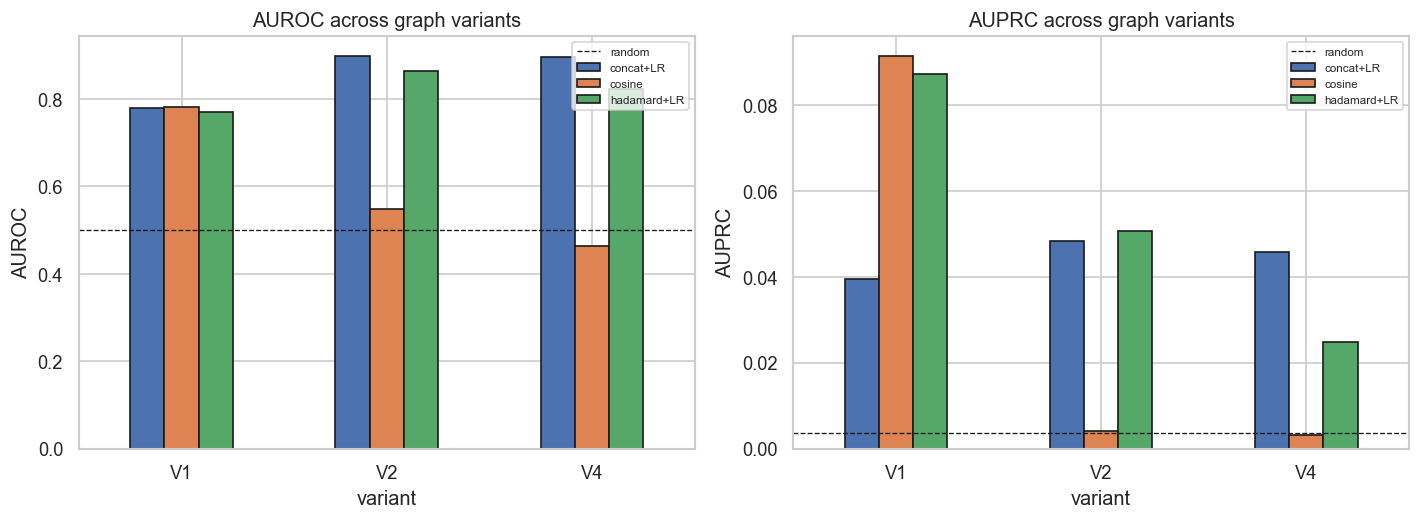

In [8]:
# Visual: AUROC bars per variant, one bar per scoring method
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric in zip(axes, ["AUROC", "AUPRC"]):
    piv = eval_df.pivot(index="variant", columns="method", values=metric)
    piv.plot.bar(ax=ax, edgecolor="k")
    ax.set(title=f"{metric} across graph variants", ylabel=metric)
    ax.tick_params(axis="x", rotation=0)
    ax.axhline(0.5 if metric == "AUROC" else float(y[idx_test].mean()),
               color="k", ls="--", lw=0.8, label="random")
    ax.legend(fontsize=7)
plt.tight_layout()


### 5b · What did widening Gene / all types do to distances?

The `graph_stats` table already recorded mean C–D shortest-path length per variant. Plot AUROC vs mean path length — the hypothesis is a monotone: the shorter the average C–D path, the easier link prediction gets, up to a point where the extra nodes start acting as noise.

In [9]:
stats_wide = stats_df.set_index("variant").merge(
    eval_df[eval_df["method"] == "concat+LR"].set_index("variant"),
    left_index=True, right_index=True, how="inner"
)
stats_wide[["n_nodes", "n_edges", "mean_path_len", "reachable_%", "AUROC", "AUPRC"]]


,n_nodes,n_edges,mean_path_len,reachable_%,AUROC,AUPRC
variant,,,,,,


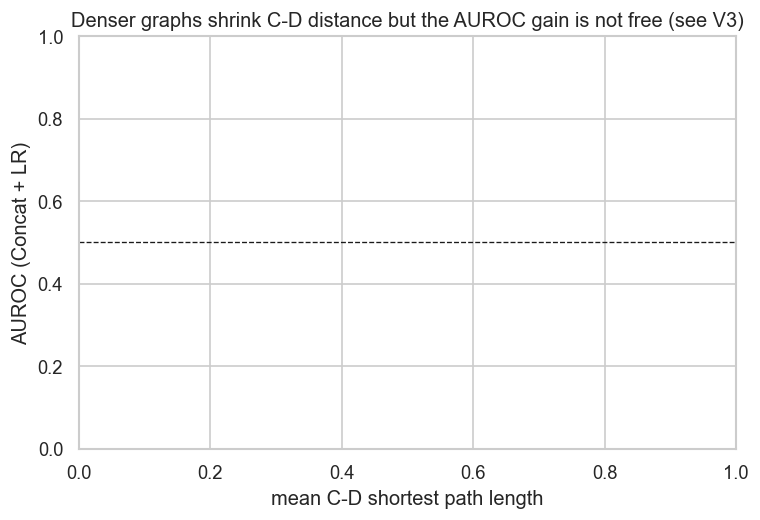

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for label, row in stats_wide.iterrows():
    ax.scatter(row["mean_path_len"], row["AUROC"], s=120)
    ax.annotate(str(label), (row["mean_path_len"], row["AUROC"]),
                xytext=(6, 4), textcoords="offset points")
ax.set(xlabel="mean C-D shortest path length",
       ylabel="AUROC (Concat + LR)",
       title="Denser graphs shrink C-D distance but the AUROC gain is not free (see V3)")
ax.axhline(0.5, color="k", ls="--", lw=0.8)
plt.tight_layout()


## 6 · Persist

In [11]:
out_meta = {
    "produced_by": "07_graph_ablation.ipynb",
    "hyperparameters": {
        "quick_run": QUICK_RUN,
        "dimensions": DIMENSIONS, "p": P, "q": Q,
        "walk_length": WALK_LENGTH, "num_walks": NUM_WALKS, "window": WINDOW,
        "hub_K": HUB_K, "seed": SEED,
    },
    "variants": stats_rows,
    "train_seconds": {k: round(v, 2) for k, v in train_times.items()},
    "results": eval_rows,
}
(ART / "predictions" / "graph_ablation_meta.json").write_text(json.dumps(out_meta, indent=2, default=str))
print("Wrote: artifacts/predictions/graph_ablation_meta.json")


Wrote: artifacts/predictions/graph_ablation_meta.json
